# Testing with Pretrained Models


## Frameworks

In [44]:
import os
import json
import base64
import io
import math
import random
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.utils import save_image, make_grid
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import cv2

import sys
sys.path.append(str(Path.cwd().parent))

from utils import DeepFakeDataset, set_global_seed  # dataset usado nas experiências anteriores

## Config & Setup

In [50]:
# =========================================================
# Config — g6 face-crop + regularização leve do D
# =========================================================
RUN_NAME = "g7_pretrained_models"

REAL_DIR = "../../deepfake_data/wiki"
BASE_OUTPUT_DIR = "outputs"
OUTPUT_DIR = os.path.join(BASE_OUTPUT_DIR, RUN_NAME)
SAMPLES_DIR = os.path.join(OUTPUT_DIR, "samples")
CHECKPOINTS_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
METRICS_DIR = os.path.join(OUTPUT_DIR, "metrics")

# IMPORTANT: MODELS ONLY WORK AT 256x256!!
IMAGE_SIZE = 256
BATCH_SIZE = 64
LATENT_DIM = 100
NGF = 64
NDF = 64
NUM_CHANNELS = 3

NUM_EPOCHS = 200
LR_G = 2e-4
LR_D = 1e-4
BETA1 = 0.5
SEED = 42
NUM_WORKERS = 0

# g6: one-sided label smoothing apenas para imagens reais.
# O alvo real do discriminador é amostrado em [0.85, 1.0].
REAL_LABEL_LOW = 0.85
REAL_LABEL_HIGH = 1.0
FAKE_LABEL = 0.0
GEN_TARGET_LABEL = 1.0

# g6: instance noise. Ajuda a impedir que D se torne perfeito demasiado cedo.
INSTANCE_NOISE_STD_INIT = 0.05
INSTANCE_NOISE_DECAY_EPOCHS = 80

# g6: dropout leve no discriminador.
DROPOUT_P = 0.20

# Face crop
USE_FACE_CROP = True
FACE_CROP_MARGIN = 0.45
FACE_DETECT_SCALE_FACTOR = 1.1
FACE_DETECT_MIN_NEIGHBORS = 5
MIN_FACE_SIZE = 20

# Usar todos os folds reais, como g5.
START_FOLD = 0
END_FOLD = 99
INTERVAL = True

# Logging / avaliação
SAMPLE_EVERY = 25
CHECKPOINT_EVERY = 10
FID_EVERY = 50
FID_NUM_IMAGES = 300      # usar 300 se for demasiado lento; 1000+ é melhor para avaliação final
COMPUTE_KID = True
SAVE_JSONL_EVERY = None

USE_EMA = True
EMA_DECAY = 0.999

ALWAYS_SAVE_EPOCHS = {1, NUM_EPOCHS}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

for folder in [OUTPUT_DIR, SAMPLES_DIR, CHECKPOINTS_DIR, PLOTS_DIR, METRICS_DIR]:
    os.makedirs(folder, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

print("Run:", RUN_NAME)
print("Device:", DEVICE)
print("Output dir:", OUTPUT_DIR)
print("Folds:", START_FOLD, "->", END_FOLD)

Run: g7_pretrained_models
Device: cuda
Output dir: outputs\g7_pretrained_models
Folds: 0 -> 99


## FaceCrop

In [51]:
# =========================================================
# Face crop transform
# =========================================================
# Usa OpenCV Haar Cascade se cv2 estiver disponível.
# Se não detetar face, faz center crop quadrado para manter o treino robusto.
try:
    import cv2
    CV2_AVAILABLE = True
    _CASCADE_PATH = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    _FACE_CASCADE = cv2.CascadeClassifier(_CASCADE_PATH)
    if _FACE_CASCADE.empty():
        print("Aviso: Haar cascade não carregou. Vou usar apenas center crop.")
        CV2_AVAILABLE = False
except Exception as e:
    cv2 = None
    _FACE_CASCADE = None
    CV2_AVAILABLE = False
    print("OpenCV não disponível. Vou usar apenas center crop. Erro:", repr(e))


def _center_square_crop(img):
    w, h = img.size
    side = min(w, h)
    left = (w - side) // 2
    top = (h - side) // 2
    return img.crop((left, top, left + side, top + side))


def _expand_to_square_box(x, y, w, h, img_w, img_h, margin=0.45):
    cx = x + w / 2
    cy = y + h / 2
    side = max(w, h) * (1.0 + margin)

    left = int(round(cx - side / 2))
    top = int(round(cy - side / 2))
    right = int(round(cx + side / 2))
    bottom = int(round(cy + side / 2))

    left = max(0, left)
    top = max(0, top)
    right = min(img_w, right)
    bottom = min(img_h, bottom)

    # Reajustar para quadrado se ficou cortado nas bordas.
    bw = right - left
    bh = bottom - top
    if bw != bh:
        side2 = min(max(bw, bh), img_w, img_h)
        cx2 = (left + right) // 2
        cy2 = (top + bottom) // 2
        left = max(0, min(img_w - side2, cx2 - side2 // 2))
        top = max(0, min(img_h - side2, cy2 - side2 // 2))
        right = left + side2
        bottom = top + side2

    return left, top, right, bottom


class FaceCropDCGANTransform:
    def __init__(
        self,
        image_size=64,
        use_face_crop=True,
        margin=0.45,
        scale_factor=1.1,
        min_neighbors=5,
        min_face_size=20,
    ):
        self.image_size = image_size
        self.use_face_crop = use_face_crop
        self.margin = margin
        self.scale_factor = scale_factor
        self.min_neighbors = min_neighbors
        self.min_face_size = min_face_size
        self.final_transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])

    def __call__(self, img):
        img = img.convert("RGB")

        if self.use_face_crop and CV2_AVAILABLE:
            arr = np.array(img)
            gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
            faces = _FACE_CASCADE.detectMultiScale(
                gray,
                scaleFactor=self.scale_factor,
                minNeighbors=self.min_neighbors,
                minSize=(self.min_face_size, self.min_face_size),
            )

            if len(faces) > 0:
                # Escolher a maior face detetada.
                x, y, w, h = max(faces, key=lambda b: b[2] * b[3])
                left, top, right, bottom = _expand_to_square_box(
                    x, y, w, h, img.size[0], img.size[1], margin=self.margin
                )
                img = img.crop((left, top, right, bottom))
            else:
                img = _center_square_crop(img)
        else:
            img = _center_square_crop(img)

        return self.final_transform(img)


transform_g6 = FaceCropDCGANTransform(
    image_size=IMAGE_SIZE,
    use_face_crop=USE_FACE_CROP,
    margin=FACE_CROP_MARGIN,
    scale_factor=FACE_DETECT_SCALE_FACTOR,
    min_neighbors=FACE_DETECT_MIN_NEIGHBORS,
    min_face_size=MIN_FACE_SIZE,
)

print("CV2 available:", CV2_AVAILABLE)
print("Face crop active:", USE_FACE_CROP and CV2_AVAILABLE)

CV2 available: True
Face crop active: True


## Reading Data

In [52]:
dataset = DeepFakeDataset(
    img_dir=REAL_DIR,
    label=1,
    transform=transform_g6,
    range_folds=[START_FOLD, END_FOLD],
    interval=INTERVAL,
    image_only=True,
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True,
)

print(f"Total de imagens reais: {len(dataset)}")
try:
    print("Folds usados:", dataset.fold_names[:5], "...", dataset.fold_names[-5:])
except Exception:
    print("Dataset carregado.")

Building ../../deepfake_data/wiki dataset with 99 folds: 100%|██████████| 99/99 [00:00<00:00, 869.81it/s]

Total de imagens reais: 29724
Folds usados: ['00', '01', '02', '03', '04'] ... ['94', '95', '96', '97', '98']


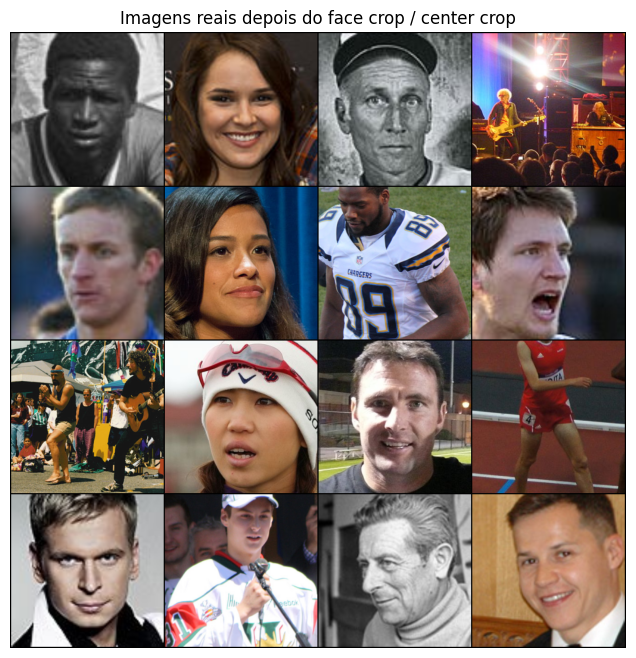

Grelha real guardada em: outputs\g7_pretrained_models\samples\real_facecrop_grid.png


In [53]:
def denorm_to_01(x): return ((x + 1) / 2).clamp(0, 1)

real_batch = next(iter(dataloader))
real_batch = denorm_to_01(real_batch[:16].cpu())

grid = make_grid(real_batch, nrow=4, padding=2)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Imagens reais depois do face crop / center crop")
plt.show()

real_grid_path = os.path.join(SAMPLES_DIR, "real_facecrop_grid.png")
save_image(grid, real_grid_path)
print("Grelha real guardada em:", real_grid_path)

## Pretrained Models

### FastGAN

In [58]:
# ============================================================
#  FastGAN  –  Instantiation & Training Loop
# ============================================================
import torch, torch.nn as nn, torch.nn.functional as F
from torchvision.utils import make_grid
from torch.cuda.amp import GradScaler, autocast
import os, json, io, base64, math
import pandas as pd
from tqdm.auto import tqdm
from PIL import Image as PILImage

import warnings
warnings.filterwarnings("ignore")

# ---- Config ----
NZ        = 256
NGF       = 64
IMG_SIZE  = 256
LR        = 2e-4
NUM_EPOCHS = 300          # adjust as needed

# ---- Dataset (uses your DeepFakeDataset with image_only=True) ----
# Example — adjust paths/folds to your setup:
# ds_real = DeepFakeDataset("path/to/real", label=0,
#                           transform=dcganFormat(IMG_SIZE),
#                           range_folds=[0,5], image_only=True)
# ds_fake = DeepFakeDataset("path/to/fake", label=1,
#                           transform=dcganFormat(IMG_SIZE),
#                           range_folds=[0,5], image_only=True)
# from torch.utils.data import ConcatDataset
# dataset = ConcatDataset([ds_real, ds_fake])
# dataloader = DataLoader(dataset, batch_size=16, shuffle=True,
#                         num_workers=2, pin_memory=True, drop_last=True)

# ---- DiffAugment ----
def DiffAugment(x, policy="color,translation,cutout"):
    for p in policy.split(","):
        x = {"color": _da_color, "translation": _da_trans, "cutout": _da_cut}[p.strip()](x)
    return x

def _da_color(x):
    b = x.size(0)
    return (x + torch.randn(b,3,1,1,device=x.device)*0.5) * (torch.rand(b,1,1,1,device=x.device)*1.4+0.3)

def _da_trans(x):
    s = int(x.size(-1)*0.125)
    return torch.roll(x, shifts=(torch.randint(-s,s+1,(1,)).item(), torch.randint(-s,s+1,(1,)).item()), dims=(2,3))

def _da_cut(x):
    b,_,h,w = x.shape; ch,cw = int(h*0.5),int(w*0.5)
    cy,cx = torch.randint(0,h,(1,)).item(), torch.randint(0,w,(1,)).item()
    mask = torch.ones_like(x)
    mask[:,:,max(0,cy-ch//2):min(h,cy+ch//2),max(0,cx-cw//2):min(w,cx+cw//2)] = 0
    return x * mask

# ---- SLE Block ----
class SLEBlock(nn.Module):
    def __init__(self, low_ch, high_ch):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(4)
        self.excite = nn.Sequential(
            nn.Conv2d(low_ch, high_ch, 4), nn.LeakyReLU(0.1),
            nn.Conv2d(high_ch, high_ch, 1), nn.Sigmoid())
    def forward(self, low, high):
        return high * self.excite(self.squeeze(low))

# ---- Generator ----
class FastGANGenerator(nn.Module):
    def __init__(self, nz=256, ngf=64, nc=3):
        super().__init__()
        self.init = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8), nn.GLU(dim=1))            # -> ngf*4 x 4x4
        def up(ci, co):
            return nn.Sequential(
                nn.Upsample(scale_factor=2, mode="nearest"),
                nn.Conv2d(ci, co*2, 3, 1, 1, bias=False),
                nn.BatchNorm2d(co*2), nn.GLU(dim=1))
        self.up1 = up(ngf*4, ngf*4)   # 8
        self.up2 = up(ngf*4, ngf*4)   # 16
        self.up3 = up(ngf*4, ngf*4)   # 32
        self.up4 = up(ngf*4, ngf*2)   # 64
        self.up5 = up(ngf*2, ngf)     # 128
        self.up6 = up(ngf, ngf//2)    # 256
        self.sle1 = SLEBlock(ngf*4, ngf*2)
        self.sle2 = SLEBlock(ngf*4, ngf)
        self.to_rgb = nn.Sequential(nn.Conv2d(ngf//2, nc, 3, 1, 1), nn.Tanh())

    def forward(self, z):
        if z.dim() == 2: z = z.unsqueeze(-1).unsqueeze(-1)
        h  = self.init(z)
        h1 = self.up1(h)
        h2 = self.up2(h1)
        h3 = self.up3(h2)
        h4 = self.sle1(h1, self.up4(h3))
        h5 = self.sle2(h2, self.up5(h4))
        h6 = self.up6(h5)
        return self.to_rgb(h6)

# ---- Discriminator ----
class FastGANDiscriminator(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super().__init__()
        def down(ci, co):
            return nn.Sequential(
                nn.Conv2d(ci, co, 4, 2, 1, bias=False),
                nn.BatchNorm2d(co), nn.LeakyReLU(0.2, True))
        self.down_big = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1), nn.LeakyReLU(0.2, True),
            down(ndf, ndf*2), down(ndf*2, ndf*4),
            down(ndf*4, ndf*8), down(ndf*8, ndf*8))
        self.head_big = nn.Conv2d(ndf*8, 1, 4, 1, 0)
        self.down_small = nn.Sequential(
            nn.AdaptiveAvgPool2d(128),
            nn.Conv2d(nc, ndf, 4, 2, 1), nn.LeakyReLU(0.2, True),
            down(ndf, ndf*2), down(ndf*2, ndf*4))
        self.head_small = nn.Conv2d(ndf*4, 1, 4, 1, 0)
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(ndf*8, ndf*4, 3, 1, 1), nn.BatchNorm2d(ndf*4), nn.GLU(dim=1),
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(ndf*2, nc, 3, 1, 1), nn.Tanh())

    def forward(self, x):
        feat = self.down_big(x)
        out_big   = self.head_big(feat).view(-1)
        out_small = self.head_small(self.down_small(x)).view(-1)
        rec = self.decoder(feat)
        return out_big, out_small, rec

# ---- Instantiate ----
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_global_seed(42)

netG = FastGANGenerator(nz=NZ, ngf=NGF, nc=3).to(DEVICE)
netD = FastGANDiscriminator(nc=3, ndf=NGF).to(DEVICE)
optG = torch.optim.Adam(netG.parameters(), lr=LR, betas=(0.5, 0.999))
optD = torch.optim.Adam(netD.parameters(), lr=LR, betas=(0.5, 0.999))
fixed_noise = torch.randn(64, NZ, device=DEVICE)

print(f"FastGAN  G: {sum(p.numel() for p in netG.parameters()):,} params")
print(f"FastGAN  D: {sum(p.numel() for p in netD.parameters()):,} params")

# ---- Saving infrastructure ----
history = []
fid_history = []
g_losses, d_losses = [], []
history_path = os.path.join(METRICS_DIR, "training_history.csv")
fid_path     = os.path.join(METRICS_DIR, "fid_kid_history.csv")
config_path  = os.path.join(OUTPUT_DIR, "run_config.json")
json.dump({"arch":"FastGAN","nz":NZ,"ngf":NGF,"img_size":IMG_SIZE,
           "lr":LR,"epochs":NUM_EPOCHS}, open(config_path,"w"), indent=2)

# ---- Calibrate sample splits ----
def _sample_line_bytes(generator, noise, nrow=8):
    generator.eval()
    with torch.no_grad():
        fake = generator(noise).detach().cpu()
        fake = (fake + 1) / 2
        grid = make_grid(fake, nrow=nrow, padding=2, normalize=False)
        arr  = (grid.permute(1,2,0).numpy()*255).clip(0,255).astype("uint8")
        buf  = io.BytesIO()
        PILImage.fromarray(arr).save(buf, format="PNG", optimize=True)
        b64  = base64.b64encode(buf.getvalue()).decode("ascii")
    generator.train()
    return len((json.dumps({"epoch":0,"format":"png","grid_b64":b64})+"\n").encode("utf-8"))

TARGET_MB = 90
TARGET_BYTES = TARGET_MB * 1024 * 1024
frame_bytes = _sample_line_bytes(netG, fixed_noise)
total_bytes = frame_bytes * NUM_EPOCHS
EPOCHS_PER_SPLIT = max(1, TARGET_BYTES // frame_bytes)
NUM_SPLITS = math.ceil(NUM_EPOCHS / EPOCHS_PER_SPLIT)
last_epochs = NUM_EPOCHS - (NUM_SPLITS - 1) * EPOCHS_PER_SPLIT
print(f"  frame: ~{frame_bytes/1024:.1f} KB  |  "
      f"{NUM_SPLITS} files: {NUM_SPLITS-1}×~{(EPOCHS_PER_SPLIT*frame_bytes)/1024/1024:.1f} MB "
      f"+ 1×~{(last_epochs*frame_bytes)/1024/1024:.1f} MB")

SAMPLE_FILES = [os.path.join(OUTPUT_DIR, f"samples_{k+1:02d}.jsonl") for k in range(NUM_SPLITS)]
for p in SAMPLE_FILES: open(p,"w").close()
def sample_file_for(epoch):
    return SAMPLE_FILES[min((epoch-1)//EPOCHS_PER_SPLIT, NUM_SPLITS-1)]

def save_samples_jsonl(epoch, generator, noise, path, nrow=8):
    generator.eval()
    with torch.no_grad():
        fake = generator(noise).detach().cpu()
        fake = (fake + 1) / 2
        grid = make_grid(fake, nrow=nrow, padding=2, normalize=False)
        arr  = (grid.permute(1,2,0).numpy()*255).clip(0,255).astype("uint8")
        buf  = io.BytesIO()
        PILImage.fromarray(arr).save(buf, format="PNG", optimize=True)
        b64  = base64.b64encode(buf.getvalue()).decode("ascii")
    generator.train()
    with open(path,"a") as f:
        f.write(json.dumps({"epoch":epoch,"format":"png","grid_b64":b64})+"\n")

# ---- Training ----
scaler_g, scaler_d = GradScaler(), GradScaler()

#for epoch in tqdm(range(1, NUM_EPOCHS+1), desc="FastGAN"):
for epoch in range(1, NUM_EPOCHS+1):
    g_run, d_run, nb = 0.0, 0.0, 0

    for batch in tqdm(dataloader, desc=f"Epoch {epoch}"):
        # handles image_only=True (bare tensor) and image_only=False (tuple)
        real = batch[0] if isinstance(batch, (list, tuple)) else batch
        bs = real.size(0)
        real = real.to(DEVICE)
        noise = torch.randn(bs, NZ, device=DEVICE)


        #print("discriminating...")

        # ---- D step ----
        optD.zero_grad(set_to_none=True)
        with autocast():
            fake = netG(noise).detach()
            ra, fa = DiffAugment(real), DiffAugment(fake)
            rb, rs, r_rec = netD(ra)
            fb, fs, _     = netD(fa)
            d_loss = (F.relu(1.-rb).mean() + F.relu(1.+fb).mean()
                    + F.relu(1.-rs).mean() + F.relu(1.+fs).mean())
            real_crop = F.adaptive_avg_pool2d(real, r_rec.size(-1))
            d_loss = d_loss + F.mse_loss(r_rec, real_crop)
        scaler_d.scale(d_loss).backward()
        scaler_d.step(optD); scaler_d.update()


        #print("generating...")

        # ---- G step ----
        optG.zero_grad(set_to_none=True)
        with autocast():
            fake = netG(torch.randn(bs, NZ, device=DEVICE))
            gb, gs, _ = netD(DiffAugment(fake))
            g_loss = -(gb.mean() + gs.mean())
        scaler_g.scale(g_loss).backward()
        scaler_g.step(optG); scaler_g.update()

        g_run += g_loss.item(); d_run += d_loss.item(); nb += 1

    
    print("saving...")

    avg_g, avg_d = g_run/max(nb,1), d_run/max(nb,1)
    g_losses.append(avg_g); d_losses.append(avg_d)
    history.append({"epoch":epoch, "g_loss":avg_g, "d_loss":avg_d})
    pd.DataFrame(history).to_csv(history_path, index=False)

    for _ in tqdm([0], desc=f"Saving epoch {epoch}", leave=False):
        save_samples_jsonl(epoch, netG, fixed_noise, sample_file_for(epoch))

    print("SAVED!")

    if epoch % 50 == 0:
        torch.save(netG.state_dict(), os.path.join(OUTPUT_DIR, f"fastgan_G_ep{epoch}.pt"))
        torch.save(netD.state_dict(), os.path.join(OUTPUT_DIR, f"fastgan_D_ep{epoch}.pt"))

print("FastGAN training complete.")

FastGAN  G: 7,223,395 params
FastGAN  D: 8,808,197 params
  frame: ~21.3 KB  |  1 files: 0×~90.0 MB + 1×~6.2 MB


FastGAN:   0%|          | 0/300 [00:40<?, ?it/s]


KeyboardInterrupt: 

### Style2Gan

In [ ]:
# ============================================================
#  StyleGAN2-ADA  –  Instantiation & Training Loop
# ============================================================
import torch, torch.nn as nn, torch.nn.functional as F
from torchvision.utils import make_grid
import os, json, io, base64, math, copy
import pandas as pd
from tqdm.auto import tqdm
from PIL import Image as PILImage

# ---- Config ----
NZ        = 512
W_DIM     = 512
BASE_CH   = 512
IMG_SIZE  = 256
LR        = 2.5e-3
R1_GAMMA  = 10.0
R1_EVERY  = 16
EMA_DECAY = 0.999
NUM_EPOCHS = 300          # adjust as needed

# ---- Dataset (same approach — image_only=True, dcganFormat) ----
# ds_real = DeepFakeDataset("path/to/real", label=0,
#                           transform=dcganFormat(IMG_SIZE),
#                           range_folds=[0,5], image_only=True)
# dataloader = DataLoader(ds_real, batch_size=8, shuffle=True,
#                         num_workers=2, pin_memory=True, drop_last=True)

# ---- Building blocks ----
class EqualLinear(nn.Module):
    def __init__(self, ci, co, lr_mul=0.01):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(co, ci) / lr_mul)
        self.bias   = nn.Parameter(torch.zeros(co))
        self.scale  = (1/math.sqrt(ci)) * lr_mul
        self.lr_mul = lr_mul
    def forward(self, x):
        return F.linear(x, self.weight*self.scale, self.bias*self.lr_mul)

class EqualConv2d(nn.Module):
    def __init__(self, ci, co, k, s=1, p=0):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(co, ci, k, k))
        self.bias   = nn.Parameter(torch.zeros(co))
        self.scale  = 1/math.sqrt(ci*k*k)
        self.s, self.p = s, p
    def forward(self, x):
        return F.conv2d(x, self.weight*self.scale, self.bias, self.s, self.p)

class ModulatedConv2d(nn.Module):
    def __init__(self, ci, co, k, style_dim, upsample=False, demodulate=True):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(co, ci, k, k))
        self.scale  = 1/math.sqrt(ci*k*k)
        self.style  = EqualLinear(style_dim, ci)
        self.upsample, self.demod = upsample, demodulate
        self.k, self.ci, self.co = k, ci, co
    def forward(self, x, s):
        b = x.size(0)
        style = self.style(s).view(b, 1, self.ci, 1, 1)
        w = self.weight.unsqueeze(0) * self.scale * style
        if self.demod:
            w = w / (w.square().sum([2,3,4], keepdim=True).sqrt() + 1e-8)
        if self.upsample:
            x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        x = x.reshape(1, b*self.ci, x.size(2), x.size(3))
        w = w.reshape(b*self.co, self.ci, self.k, self.k)
        x = F.conv2d(x, w, padding=self.k//2, groups=b)
        return x.reshape(b, self.co, x.size(2), x.size(3))

class StyleBlock(nn.Module):
    def __init__(self, ci, co, k, style_dim, upsample=False):
        super().__init__()
        self.conv = ModulatedConv2d(ci, co, k, style_dim, upsample=upsample)
        self.noise_scale = nn.Parameter(torch.zeros(1))
        self.bias = nn.Parameter(torch.zeros(co))
    def forward(self, x, s):
        x = self.conv(x, s)
        x = x + self.noise_scale * torch.randn(x.size(0),1,x.size(2),x.size(3), device=x.device)
        return F.leaky_relu(x + self.bias.view(1,-1,1,1), 0.2)

class ToRGB(nn.Module):
    def __init__(self, ci, style_dim):
        super().__init__()
        self.conv = ModulatedConv2d(ci, 3, 1, style_dim, demodulate=False)
        self.bias = nn.Parameter(torch.zeros(3))
    def forward(self, x, s):
        return self.conv(x, s) + self.bias.view(1,-1,1,1)

class MappingNetwork(nn.Module):
    def __init__(self, nz, w_dim, n_layers=8):
        super().__init__()
        layers = [EqualLinear(nz, w_dim), nn.LeakyReLU(0.2)]
        for _ in range(n_layers-1):
            layers += [EqualLinear(w_dim, w_dim), nn.LeakyReLU(0.2)]
        self.net = nn.Sequential(*layers)
    def forward(self, z):
        return self.net(F.normalize(z, dim=1))

# ---- Generator ----
class StyleGAN2Generator(nn.Module):
    def __init__(self, nz=512, w_dim=512, base_ch=512, img_size=256):
        super().__init__()
        self.mapping = MappingNetwork(nz, w_dim)
        self.const   = nn.Parameter(torch.randn(1, base_ch, 4, 4))
        log2 = int(math.log2(img_size))
        ch = {4:base_ch, 8:base_ch, 16:base_ch, 32:base_ch//2,
              64:base_ch//4, 128:base_ch//8, 256:base_ch//16}

        self.style0  = StyleBlock(base_ch, base_ch, 3, w_dim)
        self.to_rgb0 = ToRGB(base_ch, w_dim)
        self.blocks  = nn.ModuleList()
        self.to_rgbs = nn.ModuleList()
        ci = base_ch
        for i in range(log2 - 2):
            res = 2**(3+i)
            co  = ch.get(res, base_ch//16)
            self.blocks.append(nn.ModuleList([
                StyleBlock(ci, co, 3, w_dim, upsample=True),
                StyleBlock(co, co, 3, w_dim)]))
            self.to_rgbs.append(ToRGB(co, w_dim))
            ci = co

    def forward(self, z):
        w   = self.mapping(z)
        x   = self.const.expand(z.size(0),-1,-1,-1)
        x   = self.style0(x, w)
        rgb = self.to_rgb0(x, w)
        for (up, ref), to_rgb in zip(self.blocks, self.to_rgbs):
            x   = ref(up(x, w), w)
            rgb = F.interpolate(rgb, scale_factor=2, mode="bilinear", align_corners=False) + to_rgb(x, w)
        return torch.tanh(rgb)

# ---- Discriminator (residual) ----
class _ResBlock(nn.Module):
    def __init__(self, ci, co):
        super().__init__()
        self.conv = nn.Sequential(
            EqualConv2d(ci, ci, 3, 1, 1), nn.LeakyReLU(0.2),
            EqualConv2d(ci, co, 3, 1, 1), nn.LeakyReLU(0.2))
        self.skip = EqualConv2d(ci, co, 1)
    def forward(self, x):
        return (F.avg_pool2d(self.conv(x), 2) + self.skip(F.avg_pool2d(x, 2))) / math.sqrt(2)

class SG2Discriminator(nn.Module):
    def __init__(self, nc=3, base_ch=512, img_size=256):
        super().__init__()
        log2 = int(math.log2(img_size))
        ch = {4:base_ch, 8:base_ch, 16:base_ch, 32:base_ch//2,
              64:base_ch//4, 128:base_ch//8, 256:base_ch//16}
        self.from_rgb = nn.Sequential(EqualConv2d(nc, ch[img_size], 1), nn.LeakyReLU(0.2))
        blocks = []
        ci = ch[img_size]
        for i in range(log2-2, 0, -1):
            co = ch.get(2**(i+2), base_ch)
            blocks.append(_ResBlock(ci, co)); ci = co
        self.body  = nn.Sequential(*blocks)
        self.final = nn.Sequential(
            EqualConv2d(ci+1, ci, 3, 1, 1), nn.LeakyReLU(0.2),
            nn.Flatten(), EqualLinear(ci*4*4, 1))

    def forward(self, x):
        x = self.body(self.from_rgb(x))
        std = x.std(dim=0, keepdim=True).mean().expand(x.size(0),1,x.size(2),x.size(3))
        return self.final(torch.cat([x,std],1)).view(-1)

# ---- ADA ----
class ADA:
    def __init__(self, target_rt=0.6, adjust_every=4, speed=5e-3):
        self.target_rt, self.adjust_every, self.speed = target_rt, adjust_every, speed
        self.p, self.rt_buf = 0.0, []

    def update(self, d_logits):
        self.rt_buf.append((d_logits.sign().mean().item()+1)/2)
        if len(self.rt_buf) >= self.adjust_every:
            rt = sum(self.rt_buf)/len(self.rt_buf)
            self.p = max(0.0, min(1.0, self.p + self.speed*(rt - self.target_rt)))
            self.rt_buf.clear()

    def augment(self, x):
        if self.p <= 0: return x
        mask = (torch.rand(x.size(0),1,1,1, device=x.device) < self.p)
        aug = x.clone()
        aug[mask.squeeze()] = torch.flip(aug[mask.squeeze()], [-1])
        return aug + torch.randn_like(aug) * 0.1 * self.p

# ---- Instantiate ----
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_global_seed(42)

netG     = StyleGAN2Generator(nz=NZ, w_dim=W_DIM, base_ch=BASE_CH, img_size=IMG_SIZE).to(DEVICE)
netD     = SG2Discriminator(nc=3, base_ch=BASE_CH, img_size=IMG_SIZE).to(DEVICE)
netG_ema = copy.deepcopy(netG).eval()

optG = torch.optim.Adam(netG.parameters(), lr=LR, betas=(0, 0.99))
optD = torch.optim.Adam(netD.parameters(), lr=LR, betas=(0, 0.99))
ada  = ADA(target_rt=0.6)

fixed_noise = torch.randn(64, NZ, device=DEVICE)

print(f"SG2-ADA  G: {sum(p.numel() for p in netG.parameters()):,} params")
print(f"SG2-ADA  D: {sum(p.numel() for p in netD.parameters()):,} params")

# ---- Saving infrastructure ----
history = []
fid_history = []
g_losses, d_losses = [], []
history_path = os.path.join(METRICS_DIR, "training_history.csv")
fid_path     = os.path.join(METRICS_DIR, "fid_kid_history.csv")
config_path  = os.path.join(OUTPUT_DIR, "run_config.json")
json.dump({"arch":"StyleGAN2-ADA","nz":NZ,"w_dim":W_DIM,"base_ch":BASE_CH,
           "img_size":IMG_SIZE,"lr":LR,"r1_gamma":R1_GAMMA,
           "epochs":NUM_EPOCHS}, open(config_path,"w"), indent=2)

# ---- Calibrate sample splits ----
def _sample_line_bytes(generator, noise, nrow=8):
    generator.eval()
    with torch.no_grad():
        fake = generator(noise).detach().cpu()
        fake = (fake + 1) / 2
        grid = make_grid(fake, nrow=nrow, padding=2, normalize=False)
        arr  = (grid.permute(1,2,0).numpy()*255).clip(0,255).astype("uint8")
        buf  = io.BytesIO()
        PILImage.fromarray(arr).save(buf, format="PNG", optimize=True)
        b64  = base64.b64encode(buf.getvalue()).decode("ascii")
    generator.train()
    return len((json.dumps({"epoch":0,"format":"png","grid_b64":b64})+"\n").encode("utf-8"))

TARGET_MB = 90
TARGET_BYTES = TARGET_MB * 1024 * 1024
frame_bytes = _sample_line_bytes(netG, fixed_noise)
total_bytes = frame_bytes * NUM_EPOCHS
EPOCHS_PER_SPLIT = max(1, TARGET_BYTES // frame_bytes)
NUM_SPLITS = math.ceil(NUM_EPOCHS / EPOCHS_PER_SPLIT)
last_epochs = NUM_EPOCHS - (NUM_SPLITS - 1) * EPOCHS_PER_SPLIT
print(f"  frame: ~{frame_bytes/1024:.1f} KB  |  "
      f"{NUM_SPLITS} files: {NUM_SPLITS-1}×~{(EPOCHS_PER_SPLIT*frame_bytes)/1024/1024:.1f} MB "
      f"+ 1×~{(last_epochs*frame_bytes)/1024/1024:.1f} MB")

SAMPLE_FILES = [os.path.join(OUTPUT_DIR, f"samples_{k+1:02d}.jsonl") for k in range(NUM_SPLITS)]
for p in SAMPLE_FILES: open(p,"w").close()
def sample_file_for(epoch):
    return SAMPLE_FILES[min((epoch-1)//EPOCHS_PER_SPLIT, NUM_SPLITS-1)]

def save_samples_jsonl(epoch, generator, noise, path, nrow=8):
    generator.eval()
    with torch.no_grad():
        fake = generator(noise).detach().cpu()
        fake = (fake + 1) / 2
        grid = make_grid(fake, nrow=nrow, padding=2, normalize=False)
        arr  = (grid.permute(1,2,0).numpy()*255).clip(0,255).astype("uint8")
        buf  = io.BytesIO()
        PILImage.fromarray(arr).save(buf, format="PNG", optimize=True)
        b64  = base64.b64encode(buf.getvalue()).decode("ascii")
    generator.train()
    with open(path,"a") as f:
        f.write(json.dumps({"epoch":epoch,"format":"png","grid_b64":b64})+"\n")

# ---- Training ----
for epoch in tqdm(range(1, NUM_EPOCHS+1), desc="SG2-ADA"):
    g_run, d_run, nb = 0.0, 0.0, 0

    for batch in tqdm(dataloader, desc=f"Epoch {epoch}", leave=False):
        real = batch[0] if isinstance(batch, (list, tuple)) else batch
        bs   = real.size(0)
        real = real.to(DEVICE)

        # ---- D step ----
        optD.zero_grad(set_to_none=True)
        with torch.no_grad():
            fake = netG(torch.randn(bs, NZ, device=DEVICE))
        d_real = netD(ada.augment(real))
        d_fake = netD(ada.augment(fake))
        d_loss = F.softplus(-d_real).mean() + F.softplus(d_fake).mean()

        # lazy R1
        if nb % R1_EVERY == 0:
            real.requires_grad_(True)
            dr1 = netD(real)
            grad, = torch.autograd.grad(dr1.sum(), real, create_graph=True)
            d_loss = d_loss + (R1_GAMMA/2) * grad.square().sum([1,2,3]).mean() * R1_EVERY
            real.requires_grad_(False)

        d_loss.backward(); optD.step()
        ada.update(d_real.detach())

        # ---- G step ----
        optG.zero_grad(set_to_none=True)
        fake = netG(torch.randn(bs, NZ, device=DEVICE))
        g_loss = F.softplus(-netD(ada.augment(fake))).mean()
        g_loss.backward(); optG.step()

        # EMA
        with torch.no_grad():
            for pe, p in zip(netG_ema.parameters(), netG.parameters()):
                pe.lerp_(p, 1 - EMA_DECAY)

        g_run += g_loss.item(); d_run += d_loss.item(); nb += 1

    avg_g, avg_d = g_run/max(nb,1), d_run/max(nb,1)
    g_losses.append(avg_g); d_losses.append(avg_d)
    history.append({"epoch":epoch, "g_loss":avg_g, "d_loss":avg_d, "ada_p":ada.p})
    pd.DataFrame(history).to_csv(history_path, index=False)

    # save sample using EMA generator
    for _ in tqdm([0], desc=f"Saving epoch {epoch}", leave=False):
        save_samples_jsonl(epoch, netG_ema, fixed_noise, sample_file_for(epoch))

    if epoch % 50 == 0:
        torch.save(netG.state_dict(), os.path.join(OUTPUT_DIR, f"sg2ada_G_ep{epoch}.pt"))
        torch.save(netG_ema.state_dict(), os.path.join(OUTPUT_DIR, f"sg2ada_Gema_ep{epoch}.pt"))
        torch.save(netD.state_dict(), os.path.join(OUTPUT_DIR, f"sg2ada_D_ep{epoch}.pt"))

print(f"SG2-ADA training complete. Final ADA p = {ada.p:.4f}")

ValueError: betas must be either both floats or both Tensors